# Cross-session RiePCA transfer for EEG covariance matrices
## Train on one session and test on the other

For Subject 1, this notebook evaluates whether the left-versus-right-hand
signal represented by RiePCA transfers across recording sessions. It runs both
directions:

1. `0train` $\rightarrow$ `1test`;
2. `1test` $\rightarrow$ `0train`.

Each direction uses the fixed value $t_0=2.213560681877434$ from the previous
experiment. The training session alone determines the AIRM distance matrix,
frozen diffusion--Fréchet references, RiePCA
mean field, principal fields, PC3--PC4 scaler, and linear SVM. The test session
is used only after all of these objects have been frozen.

The two directions have independently fitted RiePCA bases. Therefore, “PC4”
in one direction is not assumed to be the same geometric field as “PC4” in
the reverse direction; classification performance may be summarized across
directions, but the fitted PC fields and SVM coefficients should be interpreted
within their own direction.


## 1. Install the dependencies

Run this cell once in a fresh Colab runtime. If Colab requests a restart,
restart the runtime and continue with Section 2.


In [1]:
%pip install -q "numpy<2.4" "scipy<1.18" "geomstats>=2.8,<3" "pyriemann>=0.8,<1" "moabb>=1.4,<2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 65.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.6/153.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.8/979.8 kB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.2/120.2 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 257.2/257.2 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 69.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.4/43.4 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.

## 2. Imports and the existing RiePCA helper

Keep the supplied RiePCA package in the same folder as this notebook. In
Colab, the cell asks you to upload it if `riepca_manifold.py` is not already
present. A supplied filename such as `riepca_manifold(2).py` is recognized and
renamed to the importable module name. The two imported objects have exactly
the same names as in the original notebook.


In [2]:
from pathlib import Path
import importlib.metadata as metadata_of_package
import shutil
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import kruskal, rankdata

from geomstats.geometry.spd_matrices import SPDAffineMetric, SPDMatrices
from moabb.datasets import BNCI2014_001
from moabb.paradigms import LeftRightImagery
from moabb.paradigms import MotorImagery
from pyriemann.estimation import Covariances


helper_path = Path("riepca_manifold.py")
if not helper_path.exists():
    candidates = sorted(Path(".").glob("riepca_manifold*.py"))
    if not candidates:
        try:
            from google.colab import files
        except ImportError as error:
            raise FileNotFoundError(
                "Put the supplied riepca_manifold Python file beside this notebook."
            ) from error

        print("Please upload the supplied riepca_manifold Python file")
        uploaded = files.upload()
        candidates = [
            Path(name)
            for name in uploaded
            if "riepca_manifold" in name and name.endswith(".py")
        ]
    if not candidates:
        raise FileNotFoundError("No riepca_manifold Python file was found.")
    shutil.copyfile(candidates[0], helper_path)

from riepca_manifold import (
    check_riepca,
    field_inner_product_gram,
    riepca_manifold,
)


pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

packages = ["numpy", "scipy", "geomstats", "pyriemann", "moabb"]
print({name: metadata_of_package.version(name) for name in packages})


{'numpy': '2.1.3', 'scipy': '1.16.3', 'geomstats': '2.8.0', 'pyriemann': '0.12', 'moabb': '1.7.1'}


In [3]:
BASE_FONTSIZE = 16
plt.rcParams.update({
    "font.size": BASE_FONTSIZE,
    "axes.labelsize": BASE_FONTSIZE,
    "xtick.labelsize": BASE_FONTSIZE,
    "ytick.labelsize": BASE_FONTSIZE,
    "legend.fontsize": BASE_FONTSIZE,
    "figure.titlesize": BASE_FONTSIZE,
})

## 3. Experimental choices


In [4]:
SUBJECT = 1
COVARIANCE_VARIANT = "raw"       # "raw" or "trace"

# Both directions are reported. Delete the second tuple if only the
# dataset-designated training-to-test direction is wanted.
SESSION_DIRECTIONS = [
    ("0train", "1test"),
    ("1test", "0train"),
]

# Frozen diffusion--Frechet reference construction, preserved from the
# supplied one-session notebook.
EPSILON = 0.004 # was 0.002
EPSILON_MODE = "absolute"        # "absolute" or "sublevel"
KNN_NEIGHBORS = 5
MAX_REFERENCES = 20               # use None to retain every component
FROZEN_MULTIPLIER = 1.0
T_0 = 2.213560681877434       # fixed from the previous experiment

# One fixed RiePCA/SVM specification for both directions.
CROSS_SESSION_TIME_MULTIPLIER = 3.0
N_COMPONENTS_TO_KEEP = 40
FIRST_PC = 3
N_CLASSIFIER_PCS = 2              # PC3 and PC4
SVM_C = 1.0

dataset = BNCI2014_001()
MOTOR_IMAGERY_TASKS = [
    "left_hand",
    "right_hand",
    #"feet",
    #"tongue",
]

paradigm = MotorImagery(
    events=MOTOR_IMAGERY_TASKS,
    n_classes=2,
    fmin=13,
    fmax=30,
)

## 4. Load raw trials and separate the two sessions

The session split happens before covariance construction. OAS covariance
estimation is trialwise, and it is nevertheless called separately for each
session to make the training/test boundary explicit.


In [5]:
def load_subject(subject):
    """Load raw trials plus their task and recording metadata."""
    signals, labels, trial_info = paradigm.get_data(
        dataset=dataset,
        subjects=[subject],
    )
    return signals, np.asarray(labels), trial_info.reset_index(drop=True)


def trace_normalize(covariances):
    """Divide every covariance matrix by its own trace."""
    traces = np.trace(covariances, axis1=1, axis2=2)
    return covariances / traces[:, None, None]


In [6]:
all_signals, all_task_labels, all_trial_info = load_subject(SUBJECT)
available_sessions = list(pd.unique(all_trial_info["session"].astype(str)))

requested_sessions = {
    session
    for direction in SESSION_DIRECTIONS
    for session in direction
}
missing_sessions = requested_sessions.difference(available_sessions)
if missing_sessions:
    raise ValueError(
        f"Requested sessions {sorted(missing_sessions)} were not found. "
        f"Available sessions are {available_sessions}."
    )

session_data = {}

for session in available_sessions:
    session_mask = (
        all_trial_info["session"].astype(str).to_numpy() == session
    )
    session_signals = all_signals[session_mask]
    session_labels = all_task_labels[session_mask]
    session_trial_info = (
        all_trial_info.loc[session_mask].reset_index(drop=True)
    )

    # This call is isolated within one already-separated session.----
    # Constructs one covariance matrix per trial
    session_raw_covariances = Covariances(
        estimator="oas"
    ).fit_transform(session_signals)

    if COVARIANCE_VARIANT == "raw":
        session_covariances = session_raw_covariances.copy()
    elif COVARIANCE_VARIANT == "trace":
        session_covariances = trace_normalize(
            session_raw_covariances
        )
    else:
        raise ValueError(
            "COVARIANCE_VARIANT must be 'raw' or 'trace'."
        )

    # An eigenvalue check verifies that the matrices is PD.
    minimum_eigenvalue = float(
        np.linalg.eigvalsh(session_covariances).min()
    )
    if minimum_eigenvalue <= 0:
        raise RuntimeError(
            f"Session {session} contains a non-SPD covariance matrix."
        )

    session_data[session] = {
        "signals": session_signals,
        "labels": np.asarray(session_labels),
        "trial_info": session_trial_info,
        "covariances": session_covariances,
    }

session_summary = pd.DataFrame([
    {
        "session": session,
        "n_trials": len(values["labels"]),
        "left_hand": int(np.sum(values["labels"] == "left_hand")),
        "right_hand": int(np.sum(values["labels"] == "right_hand")),
        "minimum_covariance_eigenvalue": float(
            np.linalg.eigvalsh(values["covariances"]).min()
        ),
    }
    for session, values in session_data.items()
])

print("Subject:", SUBJECT)
print("Raw signal array:", all_signals.shape)
display(session_summary)


INFO:moabb.datasets.download:MNE_DATA is not already configured. It will be set to default location in the home directory - /root/mne_data
All datasets will be downloaded to this location, if anything is already downloaded, please move manually to this location


Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)
This is nemar-py 0.3.0.
Preparing to download nm000139 from https://data.nemar.org/


INFO:httpx:HTTP Request: GET https://data.nemar.org/nm000139/ "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://data.nemar.org/nm000139/metadata.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://data.nemar.org/nm000139/v1.0.2/manifest.json "HTTP/1.1 200 OK"


Retrieving 5 of 769 manifest files (16 concurrent downloads).
primary backend failed; falling back to next layer: 'README.md' is not annexed (no sha256/md5 checksum on the manifest entry); the S3 backend has nothing to fetch.


Overall:   0%|          | 0.00/12.6k [00:00<?, ?B/s]

...

INFO:moabb.datasets.download:Filling A01T.mat from the local NEMAR store instead of downloading https://lampx.tugraz.at/~bci/database/001-2014/A01T.mat.


Finished downloading nm000139 v1.0.2.


/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/dist-packages/moabb/datasets/bnci/base.py:456: FutureWarning: Montage name 'standard_1005' is deprecated and will be removed in MNE 1.14. Use 'colin27_1005' instead.
  montage = make_standard_montage("standard_1005")
/usr/local/lib/python3.13/di

Subject: 1
Raw signal array: (288, 22, 1001)


,session,n_trials,left_hand,right_hand,minimum_covariance_eigenvalue
0,0train,144,72,72,0.036674
1,1test,144,72,72,0.032516


## 5. Affine-invariant geometry

The dataset lies on $\operatorname{SPD}(22)$ with the affine-invariant metric

$$
g_C(U,V)=\operatorname{tr}(C^{-1}UC^{-1}V).
$$

Its induced distance is

$$
d_{\mathrm{AI}}(C,D)
=\left\|\log\!\left(C^{-1/2}DC^{-1/2}\right)\right\|_F.
$$


In [7]:
def make_spd_space(n_channels):
    '''Create SPD(n_channels) with the affine-invariant metric.'''
    space = SPDMatrices(n_channels, equip=False)
    space.equip_with_metric(SPDAffineMetric)
    return space

In [8]:
first_session = SESSION_DIRECTIONS[0][0] # first session of the first session_direction
n_channels = session_data[first_session]["covariances"].shape[-1]
space = make_spd_space(n_channels)

print("Manifold:", f"SPD({n_channels})")
print("Manifold dimension:", space.dim)


Manifold: SPD(22)
Manifold dimension: 253


## 6. Geodesic-Gaussian observation fields

For covariance $C_i$ and reference $R_a$, the notebook uses

$$
F_{C_i}(R_a)=\frac{1}{2t}
\exp\!\left[-\frac{d_{\mathrm{AI}}(R_a,C_i)^2}{4t}\right]
\operatorname{Log}_{R_a}(C_i).
$$

As in the original notebook, the common factor $(4\pi t)^{-253/2}$ is omitted.
At one fixed $t$, this does not change the principal fields or explained-
variance ratios. It does rescale scores, eigenvalues, and total variance, so
raw eigenvalues or raw total variance should not be compared across heat times.


In [9]:
def unnormalized_geodesic_gaussian_fields(
    data_points,
    reference_points,
    t,
    space,
):
    '''Construct F_Y(R), batching over observations at each reference.

    Every field value at a fixed reference lies in the same tangent space, so
    Geomstats can evaluate the whole column in one call. The result is
    bit-identical to the per-pair loop and roughly four times faster on
    SPD(22); a backend that refuses the batch falls back to the loop.
    '''
    metric = space.metric
    data_points = np.asarray(data_points)
    reference_points = np.asarray(reference_points)
    n_observations = len(data_points)

    fields = np.empty(
        (n_observations, len(reference_points)) + data_points.shape[1:]
    )
    for a, reference in enumerate(reference_points):
        try:
            distance_squared = np.atleast_1d(
                np.asarray(metric.squared_dist(reference, data_points), dtype=float)
            )
            logarithms = np.asarray(
                metric.log(data_points, base_point=reference), dtype=float
            )
            if distance_squared.shape[0] != n_observations:
                raise ValueError("unbatched backend")
        except Exception:
            distance_squared = np.asarray([
                float(metric.squared_dist(reference, observation))
                for observation in data_points
            ])
            logarithms = np.stack([
                np.asarray(metric.log(observation, base_point=reference), dtype=float)
                for observation in data_points
            ])

        weight = np.exp(-distance_squared.reshape(-1) / (4.0 * t)) / (2.0 * t)
        fields[:, a] = weight.reshape((-1,) + (1,) * (logarithms.ndim - 1)) * logarithms

    return fields


## 7. Diffusion--Frechet reference selection

On the finite covariance cloud, define

$$
\widetilde\rho_t(R)=\frac1n\sum_{i=1}^n
\exp\!\left[-\frac{d_{\mathrm{AI}}(R,C_i)^2}{8t}\right],
\qquad
\widetilde\Phi_t(R)=2-2\widetilde\rho_t(R).
$$

Local minima of $\widetilde\Phi_t$ identify high-density regions. The existing
helper forms their epsilon-preimage components and selects one affine-invariant
medoid per component. The small internal k-nearest-neighbor graph is used only
to define adjacency while finding these finite-cloud components; it is not a
prediction graph, and RiePCA itself is not GraphPCA.

Because $\widetilde\Phi_t$ depends on $t$, both the reference locations and
their number may change with $t$. The helper block below is copied verbatim.


In [10]:
def pairwise_squared_distances(covariances, space):
    '''Return all affine-invariant squared distances.

    pyRiemann's vectorised AIRM distance agrees with the Geomstats metric to
    1.7e-14 relative and is about ten times faster, which matters because this
    matrix is rebuilt in every cross-validation fold. The Geomstats path is
    kept as the fallback and as the definition of record.
    '''
    covariances = np.asarray(covariances)
    try:
        from pyriemann.utils.distance import pairwise_distance

        return np.asarray(pairwise_distance(covariances, metric="riemann", squared=True))
    except Exception:
        n_observations = len(covariances)
        distance_squared = np.zeros((n_observations, n_observations))
        for i in range(n_observations):
            for j in range(i + 1, n_observations):
                value = float(
                    space.metric.squared_dist(covariances[i], covariances[j])
                )
                distance_squared[i, j] = value
                distance_squared[j, i] = value
        return distance_squared


def base_heat_time(distance_squared):
    '''Compute t0 from a training-only squared-distance matrix.'''
    upper_triangle = distance_squared[
        np.triu_indices(len(distance_squared), k=1) # selects entries strictly above the diagonal
    ]
    median_distance_squared = np.median(upper_triangle)
    if not np.isfinite(median_distance_squared) or median_distance_squared <= 0:
        raise ValueError("Could not obtain a positive heat-time scale.")
    return median_distance_squared / 4.0


def symmetric_knn_neighbors(distance_squared, n_neighbors):
    '''Construct an undirected k-nearest-neighbor graph.'''
    n_observations = len(distance_squared)
    k = min(int(n_neighbors), n_observations - 1)
    neighbors = [set() for _ in range(n_observations)]

    for i in range(n_observations):
        order = np.argsort(distance_squared[i], kind="stable")
        nearest = [j for j in order if j != i][:k]
        for j in nearest:
            neighbors[i].add(int(j))
            neighbors[int(j)].add(i)

    return [sorted(values) for values in neighbors]


def component_containing(mask, anchor, neighbors):
    '''Find one graph component inside a Boolean mask.'''
    if not mask[anchor]:
        return np.asarray([anchor], dtype=int)

    visited = {int(anchor)}
    stack = [int(anchor)]
    while stack:
        current = stack.pop()
        for other in neighbors[current]:
            if mask[other] and other not in visited:
                visited.add(other)
                stack.append(other)
    return np.asarray(sorted(visited), dtype=int)


def all_components(mask, neighbors):
    '''Find every graph component inside a Boolean mask.'''
    remaining = set(np.flatnonzero(mask).tolist())
    components = []

    while remaining:
        anchor = min(remaining)
        component = component_containing(mask, anchor, neighbors)
        components.append(component)
        remaining.difference_update(component.tolist())

    return components


def graph_local_minima(values, neighbors):
    '''Return graph-local minima, collapsing adjacent numerical ties.'''
    scale = max(float(np.max(np.abs(values))), 1.0)
    tolerance = 1e-12 * scale
    minima = []

    for i, adjacent in enumerate(neighbors):
        if all(values[i] <= values[j] + tolerance for j in adjacent):
            tied_earlier = any(
                j < i and abs(values[i] - values[j]) <= tolerance
                for j in adjacent
            )
            if not tied_earlier:
                minima.append(i)

    return np.asarray(minima, dtype=int)


def diffusion_frechet_references(
    covariances,
    t,
    space,
    *,
    distance_squared=None,
    mu=None,
    epsilon=EPSILON,
    epsilon_mode=EPSILON_MODE,
    n_neighbors=KNN_NEIGHBORS,
    max_references=MAX_REFERENCES,
):
    '''Choose one AIRM medoid per diffusion--Frechet preimage component.'''
    covariances = np.asarray(covariances)
    n_observations = len(covariances)
    if n_observations < 2:
        raise ValueError("At least two training covariances are required.")
    if epsilon <= 0:
        raise ValueError("epsilon must be positive.")
    if epsilon_mode not in {"absolute", "sublevel"}:
        raise ValueError("epsilon_mode must be 'absolute' or 'sublevel'.")

    if mu is None:
        mu = np.full(n_observations, 1.0 / n_observations)
    else:
        mu = np.asarray(mu, dtype=float)
        mu = mu / mu.sum()

    if distance_squared is None:
        distance_squared = pairwise_squared_distances(covariances, space)

    neighbors = symmetric_knn_neighbors(distance_squared, n_neighbors)
    density = np.exp(-distance_squared / (8.0 * t)) @ mu
    potential = 2.0 - 2.0 * density
    minima = graph_local_minima(potential, neighbors)
    if minima.size == 0:
        minima = np.asarray([int(np.argmin(potential))])

    scale = max(float(np.max(np.abs(potential))), 1.0)
    tolerance = 1e-12 * scale
    union_mask = np.zeros(n_observations, dtype=bool)

    # Construct a region around each minimum
    for anchor in minima:
        potential_at_minimum = potential[anchor]
        width = 2.0 * float(epsilon) * density[anchor]
        stronger = minima[
            potential[minima] < potential_at_minimum - tolerance
        ]

        # Define the potential mask
        def component_at(candidate_width):
            if epsilon_mode == "absolute":
                mask = (
                    np.abs(potential - potential_at_minimum)
                    <= candidate_width
                )
            else:
                mask = potential <= potential_at_minimum + candidate_width
            mask[anchor] = True
            return component_containing(mask, int(anchor), neighbors)

        component = component_at(width)
        if np.intersect1d(component, stronger).size:
            low = 0.0
            high = width
            separated = np.asarray([anchor], dtype=int)
            for _ in range(30):
                middle = 0.5 * (low + high)
                candidate = component_at(middle)
                if np.intersect1d(candidate, stronger).size:
                    high = middle
                else:
                    low = middle
                    separated = candidate
            component = separated

        union_mask[component] = True

    components = all_components(union_mask, neighbors)
    components.sort(key=lambda component: float(np.min(potential[component])))
    n_components_before_cap = len(components)
    if max_references is not None:
        components = components[: int(max_references)]
    cap_was_active = len(components) < n_components_before_cap
    if cap_was_active:
        warnings.warn(
            f"The reference cap retained {len(components)} of "
            f"{n_components_before_cap} preimage components. "
            "Set MAX_REFERENCES=None to retain the full construction.",
            RuntimeWarning,
        )

    # Select one medoid per component
    distances = np.sqrt(np.maximum(distance_squared, 0.0))
    reference_indices = []
    for component in components:
        local_weights = mu[component]
        local_weights = local_weights / local_weights.sum()
        costs = distances[np.ix_(component, component)] @ local_weights
        reference_indices.append(int(component[int(np.argmin(costs))]))

    reference_indices = np.asarray(reference_indices, dtype=int)
    if len(reference_indices) < 2:
        warnings.warn(
            f"The diffusion-Frechet construction returned "
            f"{len(reference_indices)} reference(s) at t={t:g}. With a single "
            "reference the direct-sum field space collapses to one tangent "
            "space and RiePCA degenerates to tangent PCA at that point. The "
            "selection kernel exp(-d^2/(8t)) is almost certainly too wide: "
            "try a smaller heat-time multiplier.",
            RuntimeWarning,
        )
    details = {
        "density": density,
        "potential": potential,
        "local_minimum_indices": minima,
        "components": components,
        "reference_indices": reference_indices,
        "n_local_minima": int(len(minima)),
        "n_references": int(len(reference_indices)),
        "n_components_before_cap": int(n_components_before_cap),
        "reference_cap_was_active": bool(cap_was_active),
    }
    return covariances[reference_indices].copy(), details


## 8. Out-of-sample projection with a frozen training fit

The following function computes field-space inner products; it does not estimate or alter any RiePCA object.


In [11]:
def project_fields_onto_training_pcs(
    centered_fields,
    fitted_training_result,
    space,
):
    """Project centered fields onto a frozen training RiePCA basis."""
    centered_fields = np.asarray(centered_fields, dtype=float)
    references = fitted_training_result.reference_points
    principal_fields = fitted_training_result.pc_fields
    reference_volumes = fitted_training_result.reference_volumes

    if centered_fields.shape[:2] != (
        len(centered_fields),
        len(references),
    ):
        raise ValueError(
            "The fields and frozen training references are incompatible."
        )

    n_components = fitted_training_result.n_components
    projected_scores = np.zeros((len(centered_fields), n_components))

    for reference_index, reference in enumerate(references):
        for component_index in range(n_components):
            principal_vector = principal_fields[
                reference_index, ..., component_index
            ]

            try:
                # Calculate AIRM inner products at each reference point
                inner_products = np.asarray(
                    space.metric.inner_product(
                        centered_fields[:, reference_index],
                        principal_vector,
                        base_point=reference,
                    ),
                    dtype=float,
                ).reshape(-1)
                if inner_products.shape != (len(centered_fields),):
                    raise ValueError("unbatched backend")
            except Exception:
                inner_products = np.asarray([
                    float(np.asarray(space.metric.inner_product(
                        field[reference_index],
                        principal_vector,
                        base_point=reference,
                    )).reshape(-1)[0])
                    for field in centered_fields
                ])

            # Calculate PC scores (where PC are from the training set) for each
            # covariance matrix in the test set
            projected_scores[:, component_index] += (
                reference_volumes[reference_index] * inner_products
            )

    return projected_scores


## 9. Strict cross-session RiePCA and SVM

For each direction, the full fitted pipeline is

$$
(t_0=2.213560681877434,\ \text{training session})
\longrightarrow
(\text{references},\ \bar{F},\ \text{PC fields})
\longrightarrow
(\text{PC3},\text{PC4})
\longrightarrow
(\text{scaler},\text{SVM}).
$$

The test session enters only through its fields evaluated at the frozen
training references and the fixed heat time derived from $t_0$.


In [12]:
from sklearn.metrics import (
    balanced_accuracy_score,
    confusion_matrix,
    recall_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


def normalized_task_labels(labels):
    return np.asarray([
        str(label).strip().lower().replace(" ", "_")
        for label in labels
    ])


def run_cross_session_direction(train_session, test_session):
    """Fit every object on train_session and evaluate on test_session."""
    training = session_data[train_session]
    testing = session_data[test_session]

    covariances_train = training["covariances"]
    covariances_test = testing["covariances"]

    # Geometry uses the training session; t0 is fixed from the prior experiment.
    distance_squared_train = pairwise_squared_distances(
        covariances_train,
        space,
    )
    t0_train = float(T_0)
    reference_selection_time_train = (
        float(FROZEN_MULTIPLIER) * t0_train
    )
    t_train = float(CROSS_SESSION_TIME_MULTIPLIER) * t0_train

    frozen_references_train, frozen_details_train = (
        diffusion_frechet_references(
            covariances_train,
            reference_selection_time_train,
            space,
            distance_squared=distance_squared_train,
        )
    )

    # Exactly one RiePCA fit in this direction.
    fitted_train = riepca_manifold(
        covariances_train,
        frozen_references_train,
        space,
        t=t_train,
        field_builder=unnormalized_geodesic_gaussian_fields,
        k_keep=N_COMPONENTS_TO_KEEP,
    )
    check_riepca(
        fitted_train,
        space,
        rtol=1e-7,
        atol=1e-7,
    )

    pc_start = FIRST_PC - 1
    pc_stop = pc_start + N_CLASSIFIER_PCS
    if fitted_train.n_components < pc_stop:
        raise RuntimeError(
            f"The {train_session} training fit retained only "
            f"{fitted_train.n_components} PCs; PC{FIRST_PC} through "
            f"PC{pc_stop} are required."
        )

    # No test-session mean or reference is estimated.
    test_raw_fields = unnormalized_geodesic_gaussian_fields(
        covariances_test,
        fitted_train.reference_points,
        fitted_train.t,
        space,
    )
    # Centered test data using the mean of the training data
    test_centered_fields = (
        test_raw_fields - fitted_train.mean_field[None, ...]
    )
    test_scores = project_fields_onto_training_pcs(
        test_centered_fields,
        fitted_train,
        space,
    )

    # Verify the projection implementation in this direction.
    training_scores_reprojected = project_fields_onto_training_pcs(
        fitted_train.centered_fields,
        fitted_train,
        space,
    )
    if not np.allclose(
        training_scores_reprojected,
        fitted_train.scores,
        rtol=1e-7,
        atol=1e-7,
    ):
        raise RuntimeError(
            "Out-of-sample projection does not reproduce training scores."
        )
    projection_max_abs_error = float(np.max(np.abs(
        training_scores_reprojected - fitted_train.scores
    )))

    X_train = np.asarray(
        fitted_train.scores[:, pc_start:pc_stop],
        dtype=float,
    )
    X_test = np.asarray(
        test_scores[:, pc_start:pc_stop],
        dtype=float,
    )

    task_labels_train = normalized_task_labels(training["labels"])
    task_labels_test = normalized_task_labels(testing["labels"])
    expected_labels = {"left_hand", "right_hand"}
    if set(task_labels_train) != expected_labels:
        raise ValueError(
            f"Unexpected training labels: {set(task_labels_train)}."
        )
    if set(task_labels_test) != expected_labels:
        raise ValueError(
            f"Unexpected test labels: {set(task_labels_test)}."
        )

    y_train = (task_labels_train == "right_hand").astype(int)
    y_test = (task_labels_test == "right_hand").astype(int)

    # Plot training PCs at the selected heat time.
    import matplotlib.pyplot as plt
    from pathlib import Path

    scores = np.asarray(fitted_train.scores)
    n_pairs = min(4, scores.shape[1] - 1)
    if n_pairs < 1:
        raise ValueError("At least two retained PCs are needed for plotting.")

    with plt.rc_context({"font.size": 16}):
        fig, axes = plt.subplots(
            1, n_pairs + 1,
            figsize=(4.5 * n_pairs + 5, 5),
            gridspec_kw={"width_ratios": [1] * n_pairs + [1.3]},
        )

        # PC1–PC2 through PC4–PC5, coloured by hand label.
        for j, ax in enumerate(axes[:-1]):
            for label, color in [
                ("right_hand", "#377eb8"),
                ("left_hand", "#e41a1c"),
            ]:
                mask = task_labels_train == label
                ax.scatter(
                    scores[mask, j],
                    scores[mask, j + 1],
                    color=color,
                    label=label.replace("_", " "),
                    s=26,
                    alpha=0.75,
                    linewidths=0,
                )

            ax.set_xlabel(f"PC{j + 1} score")
            ax.set_ylabel(f"PC{j + 2} score")
            ax.axhline(0, color="black", linewidth=0.6, alpha=0.35)
            ax.axvline(0, color="black", linewidth=0.6, alpha=0.35)
            ax.grid(alpha=0.2)
            ax.set_box_aspect(1)

        # Explained variance from the same training fit.
        n_plot = min(8, fitted_train.n_components)
        pcs = np.arange(1, n_plot + 1)
        ax = axes[-1]

        ax.bar(
            pcs,
            fitted_train.explained_variance_ratio[:n_plot],
            color="#4c78a8",
        )
        ax.set_xlabel("principal component")
        ax.set_ylabel("explained variance per PC", color="#4c78a8")
        ax.tick_params(axis="y", labelcolor="#4c78a8")
        ax.set_xticks(pcs)
        ax.set_ylim(bottom=0)
        ax.set_axisbelow(True)
        ax.grid(alpha=0.2)

        cumulative_ax = ax.twinx()
        cumulative_ax.plot(
            pcs,
            fitted_train.cumulative_explained_variance_ratio[:n_plot],
            "o-",
            color="#f58518",
        )
        cumulative_ax.set_ylabel(
            "cumulative explained variance", color="#f58518"
        )
        cumulative_ax.tick_params(axis="y", labelcolor="#f58518")
        cumulative_ax.set_ylim(0, 1.02)

        """
        fig.suptitle(
            f"Subject {SUBJECT} | training: {train_session} | "
            f"t/t0={t_train / t0_train:g} | t0={t0_train:.6g}",
            y=0.95,
        )
        """

        handles, legend_labels = axes[0].get_legend_handles_labels()

        legend_labels = [f"task: {label}" for label in legend_labels]

        fig.legend(
            handles,
            legend_labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.93),
            ncol=2,
            frameon=False,
        )
        fig.tight_layout(rect=(0, 0, 1, 0.90))

        # Save this figure as PNG and PDF.
        figure_directory = Path("figures")
        figure_directory.mkdir(parents=True, exist_ok=True)

        multiplier_tag = (
            f"{CROSS_SESSION_TIME_MULTIPLIER:g}".replace(".", "p")
        )
        figure_stem = (
            f"subject{SUBJECT:02d}_{COVARIANCE_VARIANT}_"
            f"{train_session}_to_{test_session}_"
            f"multiplier{multiplier_tag}_pre_SVM"
        )

        png_path = figure_directory / f"{figure_stem}.png"
        pdf_path = figure_directory / f"{figure_stem}.pdf"

        fig.savefig(png_path, dpi=150, bbox_inches="tight")
        fig.savefig(pdf_path, bbox_inches="tight")

        print("Saved:", png_path)
        print("Saved:", pdf_path)

        plt.show()
        plt.close(fig)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm = SVC(
        kernel="linear",
        C=SVM_C,
        class_weight="balanced",
    )
    svm.fit(X_train_scaled, y_train)
    predictions = svm.predict(X_test_scaled)

    confusion = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1],
    )

    return {
        "train_session": train_session,
        "test_session": test_session,
        "distance_squared_train": distance_squared_train,
        "t0_train": t0_train,
        "reference_selection_time_train": (
            reference_selection_time_train
        ),
        "t_train": t_train,
        "frozen_details_train": frozen_details_train,
        "fitted_train": fitted_train,
        "test_scores": test_scores,
        "projection_max_abs_error": projection_max_abs_error,
        "pc_names": [
            f"PC{number}"
            for number in range(FIRST_PC, pc_stop + 1)
        ],
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler,
        "svm": svm,
        "predictions": predictions,
        "confusion_matrix": confusion,
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            predictions,
        ),
        "left_hand_recall": recall_score(
            y_test,
            predictions,
            pos_label=0,
        ),
        "right_hand_recall": recall_score(
            y_test,
            predictions,
            pos_label=1,
        ),
    }



Running 0train -> 1test


/tmp/ipykernel_2055/3648382831.py:11: DeprecationWarning: pyriemann.utils.distance is deprecated and will be removed in 0.14.0; use pyriemann.geometry.distance instead.
  from pyriemann.utils.distance import pairwise_distance


Saved: figures/subject01_raw_0train_to_1test_multiplier3_pre_SVM.png
Saved: figures/subject01_raw_0train_to_1test_multiplier3_pre_SVM.pdf


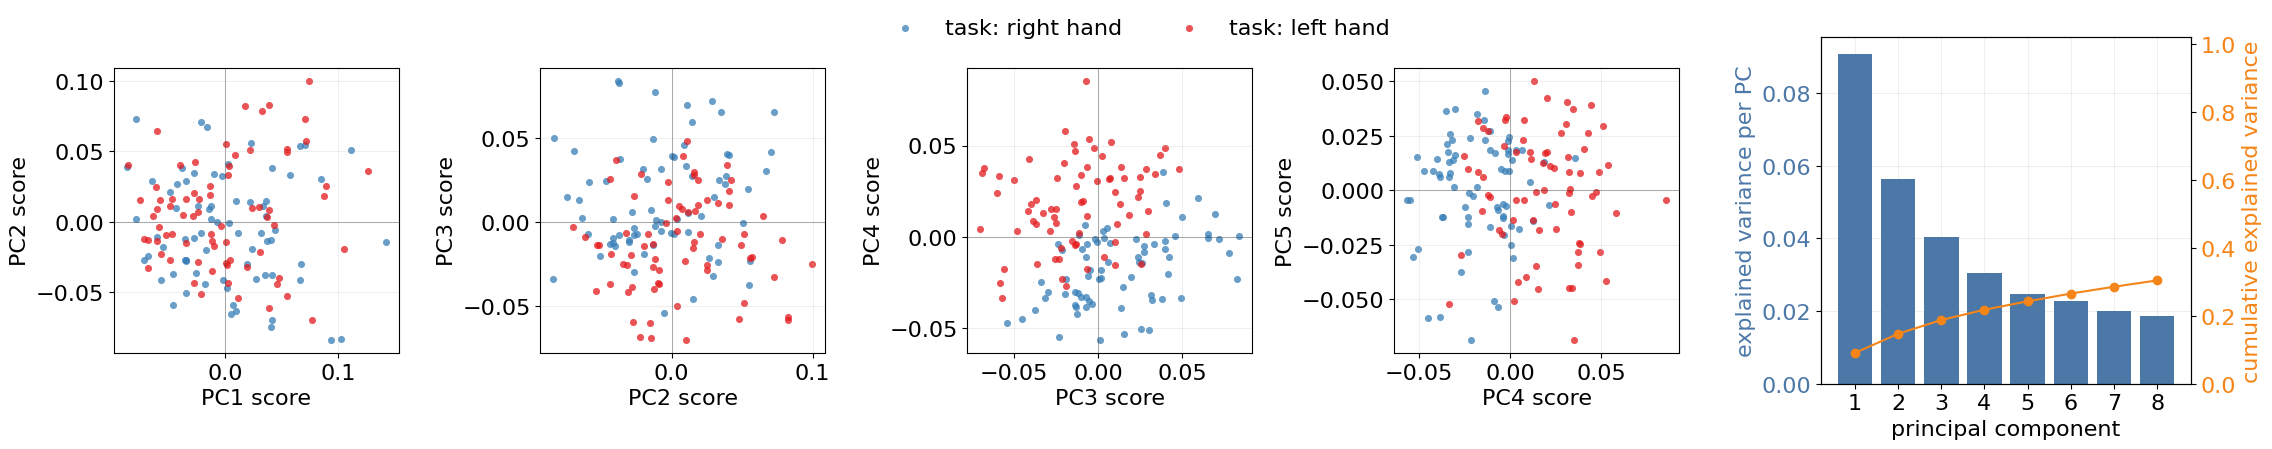

0train -> 1test


,predicted_left_hand,predicted_right_hand
true_left_hand,63,9
true_right_hand,6,66



Running 1test -> 0train
Saved: figures/subject01_raw_1test_to_0train_multiplier3_pre_SVM.png
Saved: figures/subject01_raw_1test_to_0train_multiplier3_pre_SVM.pdf


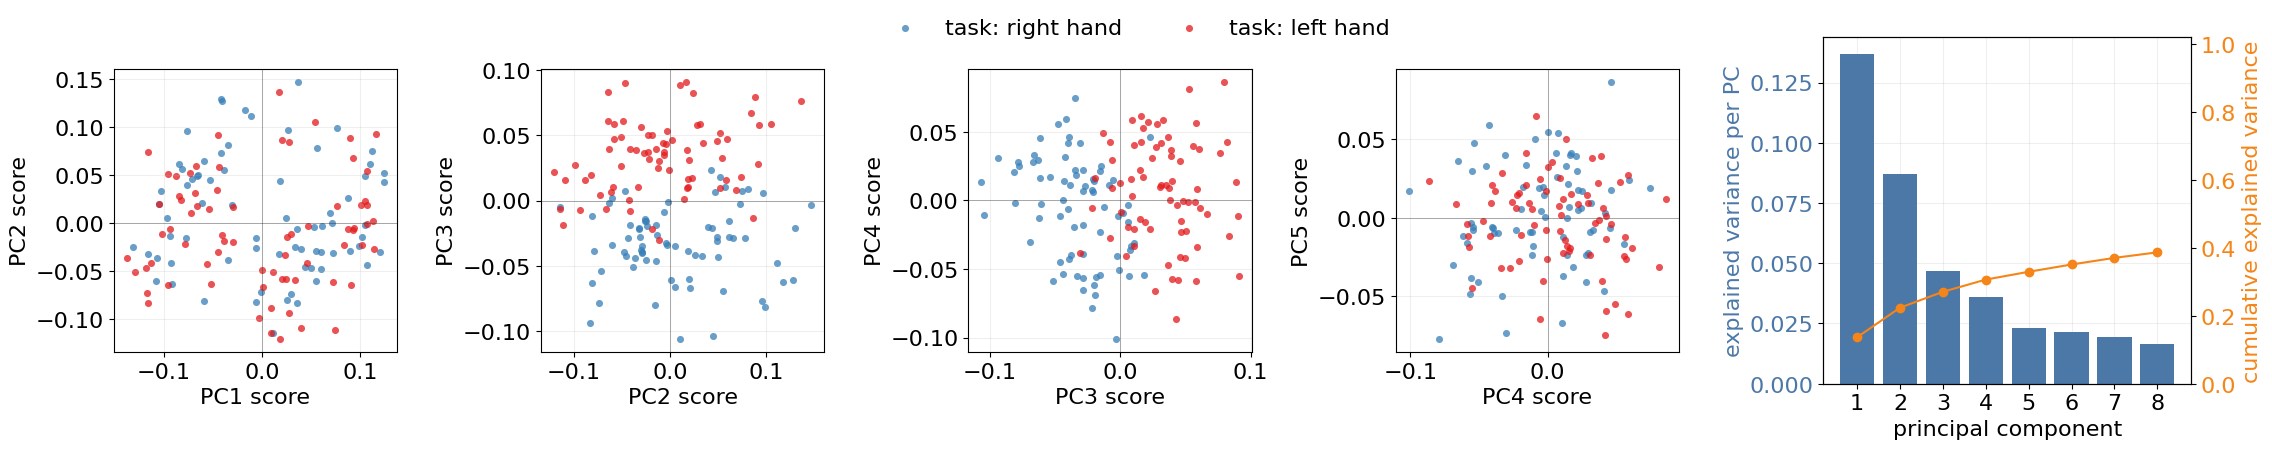

1test -> 0train


,predicted_left_hand,predicted_right_hand
true_left_hand,61,11
true_right_hand,7,65


,direction,n_train,n_test,t0_train,t_train,n_training_references,projection_max_abs_error,balanced_accuracy,left_hand_recall,right_hand_recall
0,0train -> 1test,144,144,2.21356,6.64068,2,4.366e-15,0.8958,0.8750,0.9167
1,1test -> 0train,144,144,2.21356,6.64068,3,4.282e-15,0.8750,0.8472,0.9028


Mean balanced accuracy across the two directions: 0.8854
saved: subject_1_cross_session_PC3_PC4_SVM_summary.csv
saved: subject_1_cross_session_PC3_PC4_scores.csv


In [13]:
cross_session_results = {}
cross_session_rows = []
cross_session_score_rows = []

for train_session, test_session in SESSION_DIRECTIONS:
    direction = f"{train_session} -> {test_session}"
    print(f"\nRunning {direction}")

    result = run_cross_session_direction(
        train_session,
        test_session,
    )
    cross_session_results[direction] = result

    cross_session_rows.append({
        "direction": direction,
        "n_train": len(result["y_train"]),
        "n_test": len(result["y_test"]),
        "t0_train": result["t0_train"],
        "t_train": result["t_train"],
        "n_training_references": int(
            result["frozen_details_train"]["n_references"]
        ),
        "projection_max_abs_error": (
            result["projection_max_abs_error"]
        ),
        "balanced_accuracy": result["balanced_accuracy"],
        "left_hand_recall": result["left_hand_recall"],
        "right_hand_recall": result["right_hand_recall"],
    })

    for split_name, session, X_values, y_values, predictions in [
        (
            "train",
            train_session,
            result["X_train"],
            result["y_train"],
            np.full(len(result["y_train"]), np.nan),
        ),
        (
            "test",
            test_session,
            result["X_test"],
            result["y_test"],
            result["predictions"].astype(float),
        ),
    ]:
        for index in range(len(y_values)):
            cross_session_score_rows.append({
                "direction": direction,
                "split": split_name,
                "session": session,
                "task": (
                    "right_hand" if y_values[index] else "left_hand"
                ),
                "PC3": X_values[index, 0],
                "PC4": X_values[index, 1],
                "predicted_class": predictions[index],
            })

    confusion_table = pd.DataFrame(
        result["confusion_matrix"],
        index=["true_left_hand", "true_right_hand"],
        columns=["predicted_left_hand", "predicted_right_hand"],
    )
    print(direction)
    display(confusion_table)

cross_session_summary = pd.DataFrame(cross_session_rows)
cross_session_scores = pd.DataFrame(cross_session_score_rows)

mean_directional_balanced_accuracy = float(
    cross_session_summary["balanced_accuracy"].mean()
)

display(cross_session_summary.style.format({
    "t0_train": "{:.6g}",
    "t_train": "{:.6g}",
    "projection_max_abs_error": "{:.3e}",
    "balanced_accuracy": "{:.4f}",
    "left_hand_recall": "{:.4f}",
    "right_hand_recall": "{:.4f}",
}))
print(
    "Mean balanced accuracy across the two directions: "
    f"{mean_directional_balanced_accuracy:.4f}"
)

summary_filename = (
    f"subject_{SUBJECT}_cross_session_PC3_PC4_SVM_summary.csv"
)
scores_filename = (
    f"subject_{SUBJECT}_cross_session_PC3_PC4_scores.csv"
)
cross_session_summary.to_csv(summary_filename, index=False)
cross_session_scores.to_csv(scores_filename, index=False)

print("saved:", summary_filename)
print("saved:", scores_filename)
